# Statistical & Distribution Analysis — 50 Indian Cities

This notebook performs memory-safe EDA on 50 selected cities from the Kaggle dataset **Indian Cities Weather 2010–2024: Dive In!**.

Dataset: https://www.kaggle.com/datasets/mukeshdevrath007/indian-5000-cities-weather-data

The raw city files are read one at a time and converted to daily summaries. This avoids loading the complete 29 GB dataset into RAM.

In [4]:
import os
import re
import glob
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.3f}".format)

OUTPUT_DIR = "/kaggle/working/weather_eda_50_cities"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Setup complete")

Setup complete


## 1. Find the Kaggle dataset files

In [5]:
# Kaggle mounts an added dataset under /kaggle/input.
csv_files = sorted(
    glob.glob("/kaggle/input/**/*.csv", recursive=True)
    + glob.glob("/kaggle/input/**/*.csv.gz", recursive=True)
)

if not csv_files:
    raise FileNotFoundError(
        "No CSV files found. Click Add Input and attach "
        "mukeshdevrath007/indian-5000-cities-weather-data."
    )

total_size_gb = sum(os.path.getsize(f) for f in csv_files) / (1024 ** 3)
print(f"CSV files found : {len(csv_files):,}")
print(f"Mounted CSV size: {total_size_gb:.2f} GB")
print("First file      :", csv_files[0])

CSV files found : 4,686
Mounted CSV size: 89.63 GB
First file      : /kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/Weather_Data_Scraping_and_Analysis/weather.csv


## 2. Select 50 geographically diverse cities

In [9]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display


def normalize_name(name):
    return re.sub(r"[^a-z0-9]", "", str(name).lower())


def get_dataset_city_name(file_path):
    filename = Path(file_path).name

    if filename.lower().endswith(".csv.gz"):
        return filename[:-7]

    return Path(filename).stem


# Create a table containing exact names from the dataset
available_df = pd.DataFrame({
    "city": [get_dataset_city_name(file) for file in csv_files],
    "file": csv_files
})

available_df["city_key"] = available_df["city"].apply(normalize_name)

# Remove duplicate city files
available_df = (
    available_df
    .drop_duplicates(subset="city_key")
    .sort_values("city")
    .reset_index(drop=True)
)


# Cities whose names were found exactly
PREFERRED_CITIES = [
    "Delhi", "Mumbai", "Chennai", "Kolkata", "Hyderabad",
    "Pune", "Ahmedabad", "Jaipur", "Lucknow", "Nagpur",
    "Indore", "Bhopal", "Patna", "Rajkot", "Agra",
    "Prayagraj", "Ranchi", "Raipur", "Cuttack", "Guwahati",
    "Imphal", "Aizawl", "Agartala", "Kohima", "Itanagar",
    "Dehradun", "Chandigarh", "Jammu", "Leh", "Amritsar",
    "Ludhiana", "Jodhpur", "Kota", "Kochi", "Coimbatore"
]

preferred_keys = {
    normalize_name(city)
    for city in PREFERRED_CITIES
}

# Select available preferred cities
selected_files = available_df[
    available_df["city_key"].isin(preferred_keys)
].copy()

# Select additional valid cities directly from the dataset
needed = 50 - len(selected_files)

remaining_files = available_df[
    ~available_df["city_key"].isin(selected_files["city_key"])
].reset_index(drop=True)

if needed > 0:
    # Evenly select cities instead of taking only alphabetical first cities
    indices = np.linspace(
        0,
        len(remaining_files) - 1,
        needed,
        dtype=int
    )

    additional_cities = remaining_files.iloc[indices]

    selected_files = pd.concat(
        [selected_files, additional_cities],
        ignore_index=True
    )

# Keep exactly 50 valid cities
selected_files = selected_files.head(50)
selected_files = selected_files[["city", "file"]]

if len(selected_files) != 50:
    raise ValueError(
        f"Only {len(selected_files)} valid city files were available."
    )

print("Total selected cities:", len(selected_files))
print("Unique cities:", selected_files["city"].nunique())

display(selected_files)

Total selected cities: 50
Unique cities: 50


,city,file
0,Agartala,/kaggle/input/datasets/mukeshdevrath007/indian...
1,Agra,/kaggle/input/datasets/mukeshdevrath007/indian...
2,Ahmedabad,/kaggle/input/datasets/mukeshdevrath007/indian...
3,Aizawl,/kaggle/input/datasets/mukeshdevrath007/indian...
4,Amritsar,/kaggle/input/datasets/mukeshdevrath007/indian...
5,Bhopal,/kaggle/input/datasets/mukeshdevrath007/indian...
6,Chandigarh,/kaggle/input/datasets/mukeshdevrath007/indian...
7,Chennai,/kaggle/input/datasets/mukeshdevrath007/indian...
8,Coimbatore,/kaggle/input/datasets/mukeshdevrath007/indian...
9,Cuttack,/kaggle/input/datasets/mukeshdevrath007/indian...


## 3. Read each city and create daily features

Column names are matched after removing units and punctuation, so the code works with common Open-Meteo header variations such as `temperature_2m (°C)`.

In [12]:
COLUMN_ALIASES = {
    "time": ["time", "datetime", "date"],
    "temperature_2m": ["temperature2m", "temp2m", "temperature"],
    "relative_humidity_2m": ["relativehumidity2m", "humidity2m", "relativehumidity"],
    "dew_point_2m": ["dewpoint2m", "dewpoint"],
    "precipitation": ["precipitation", "precip"],
    "rain": ["rain"],
    "wind_speed_10m": ["windspeed10m", "wind10m"],
    "wind_speed_100m": ["windspeed100m", "wind100m"],
    "wind_gusts_10m": ["windgusts10m", "windgust10m", "windgusts"],
    "cloud_cover": ["cloudcover", "cloudiness"],
    "cloud_cover_low": ["cloudcoverlow", "lowcloudcover"],
    "cloud_cover_mid": ["cloudcovermid", "midcloudcover"],
    "cloud_cover_high": ["cloudcoverhigh", "highcloudcover"],
    "pressure_msl": ["pressuremsl", "sealevelpressure"],
    "surface_pressure": ["surfacepressure"],
}

def match_columns(columns):
    normalized = {col: normalize_name(col) for col in columns}
    matched = {}
    for standard, aliases in COLUMN_ALIASES.items():
        aliases = [normalize_name(a) for a in aliases]
        exact = [c for c, n in normalized.items() if n in aliases]
        prefix = [c for c, n in normalized.items() if any(n.startswith(a) for a in aliases)]
        if exact or prefix:
            matched[standard] = (exact or prefix)[0]
    return matched

def daily_summary(file, city):
    header = pd.read_csv(file, nrows=0).columns.tolist()
    matched = match_columns(header)
    if "time" not in matched:
        raise ValueError("No date/time column found")
    if "temperature_2m" not in matched:
        raise ValueError("No temperature column found")

    usecols = list(dict.fromkeys(matched.values()))
    raw = pd.read_csv(file, usecols=usecols, low_memory=False)
    raw = raw.rename(columns={original: standard for standard, original in matched.items()})
    raw["date"] = pd.to_datetime(raw.pop("time"), errors="coerce", utc=True).dt.tz_localize(None).dt.floor("D")
    raw = raw.dropna(subset=["date"])

    for col in raw.columns.difference(["date"]):
        raw[col] = pd.to_numeric(raw[col], errors="coerce", downcast="float")

    grouped = raw.groupby("date", sort=False)
    daily = pd.DataFrame(index=grouped.size().index)
    daily["city"] = city

    def add(source, outputs):
        if source in raw.columns:
            for output, operation in outputs.items():
                daily[output] = grouped[source].agg(operation)

    add("temperature_2m", {"temp_mean": "mean", "temp_max": "max", "temp_min": "min"})
    add("relative_humidity_2m", {"humidity_mean": "mean"})
    add("dew_point_2m", {"dew_mean": "mean"})
    add("precipitation", {"precip_total": "sum", "precip_max": "max"})
    if "precip_total" not in daily.columns:
        add("rain", {"precip_total": "sum", "precip_max": "max"})
    add("wind_speed_10m", {"wind_mean_10m": "mean", "wind_max_10m": "max"})
    add("wind_speed_100m", {
        "wind_mean_100m": "mean", "wind_max_100m": "max", "wind_std_100m": "std"
    })
    add("wind_gusts_10m", {"wind_gusts_max": "max"})
    add("cloud_cover", {"cloud_mean": "mean"})
    add("cloud_cover_low", {"cloud_low_mean": "mean"})
    add("cloud_cover_mid", {"cloud_mid_mean": "mean"})
    add("cloud_cover_high", {"cloud_high_mean": "mean"})
    add("pressure_msl", {"pressure_mean": "mean"})
    add("surface_pressure", {"surface_pressure_mean": "mean"})

    if "precip_total" in daily.columns:
        daily["rain_occurred"] = (daily["precip_total"] > 0).astype("int8")

    daily = daily.reset_index()
    del raw
    gc.collect()
    return daily, matched

In [13]:
daily_frames = []
load_log = []

for number, row in selected_files.iterrows():
    try:
        city_daily, matched = daily_summary(row["file"], row["city"])
        if not city_daily.empty:
            daily_frames.append(city_daily)
            load_log.append({
                "city": row["city"], "status": "loaded",
                "days": len(city_daily), "columns_matched": len(matched), "error": ""
            })
        else:
            load_log.append({"city": row["city"], "status": "skipped", "days": 0,
                             "columns_matched": len(matched), "error": "no valid dates"})
    except Exception as exc:
        load_log.append({"city": row["city"], "status": "skipped", "days": 0,
                         "columns_matched": 0, "error": str(exc)[:160]})

    if (number + 1) % 10 == 0:
        print(f"Processed {number + 1}/50 files")

load_log = pd.DataFrame(load_log)
display(load_log)

if not daily_frames:
    raise RuntimeError("No files could be loaded. Review the load log and dataset structure.")

df = pd.concat(daily_frames, ignore_index=True)
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

print("\nFinal daily dataset shape:", df.shape)
print("Cities loaded:", df["city"].nunique())
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())

# Save the much smaller daily table for reuse in later Kaggle sessions.
daily_path = os.path.join(OUTPUT_DIR, "weather_50_cities_daily.csv")
df.to_csv(daily_path, index=False)
print("Saved:", daily_path)

Processed 10/50 files
Processed 20/50 files
Processed 30/50 files
Processed 40/50 files
Processed 50/50 files


,city,status,days,columns_matched,error
0,Agartala,loaded,5164,15,
1,Agra,loaded,5164,15,
2,Ahmedabad,loaded,5164,15,
3,Aizawl,loaded,5164,15,
4,Amritsar,loaded,5164,15,
5,Bhopal,loaded,5164,15,
6,Chandigarh,loaded,5164,15,
7,Chennai,loaded,5164,15,
8,Coimbatore,loaded,5164,15,
9,Cuttack,loaded,5164,15,



Final daily dataset shape: (253036, 24)
Cities loaded: 49
Date range: 2010-01-01 to 2024-02-20
Saved: /kaggle/working/weather_eda_50_cities/weather_50_cities_daily.csv


## 4. Dataset overview and data-quality checks

In [14]:
print("Shape             :", df.shape)
print("Number of cities  :", df["city"].nunique())
print("Number of columns :", df.shape[1])
print("Memory used       :", round(df.memory_usage(deep=True).sum() / 1024**2, 2), "MB")
print("Duplicate city-days:", df.duplicated(["city", "date"]).sum())

print("\nData types:")
display(df.dtypes.rename("dtype").to_frame())

print("\nSample rows:")
display(df.head())

coverage = (df.groupby("city")
              .agg(first_date=("date", "min"), last_date=("date", "max"), days=("date", "size"))
              .sort_values("days"))
display(coverage)

Shape             : (253036, 24)
Number of cities  : 49
Number of columns : 24
Memory used       : 36.05 MB
Duplicate city-days: 0

Data types:


,dtype
date,datetime64[ns]
city,object
temp_mean,float32
temp_max,float32
temp_min,float32
humidity_mean,float32
dew_mean,float32
precip_total,float32
precip_max,float32
wind_mean_10m,float32



Sample rows:


,date,city,temp_mean,temp_max,temp_min,humidity_mean,dew_mean,precip_total,precip_max,wind_mean_10m,wind_max_10m,wind_mean_100m,wind_max_100m,wind_std_100m,wind_gusts_max,cloud_mean,cloud_low_mean,cloud_mid_mean,cloud_high_mean,pressure_mean,surface_pressure_mean,rain_occurred,year,month
0,2010-01-01,Agartala,17.457,23.074,12.273,67.274,10.813,0.000,0.000,7.748,9.504,15.583,22.862,4.182,24.120,4.100,2.208,0.000,7.042,1015.096,1013.784,0,2010,1
1,2010-01-02,Agartala,18.259,24.774,11.474,70.592,12.321,0.000,0.000,7.344,9.470,13.378,19.882,4.023,24.480,1.038,0.000,0.000,3.458,1015.017,1013.708,0,2010,1
2,2010-01-03,Agartala,18.236,25.374,10.974,75.072,13.163,0.000,0.000,6.740,9.339,11.021,17.340,3.936,18.360,11.438,12.708,0.000,0.000,1013.567,1012.260,0,2010,1
3,2010-01-04,Agartala,18.040,23.774,12.373,76.026,13.388,0.000,0.000,6.326,8.655,11.158,17.874,4.678,18.360,11.625,10.083,0.000,8.500,1011.521,1010.216,0,2010,1
4,2010-01-05,Agartala,17.969,24.024,12.123,73.595,12.738,0.000,0.000,7.252,8.891,14.312,20.593,4.100,21.600,0.000,0.000,0.000,0.000,1011.658,1010.353,0,2010,1


,first_date,last_date,days
city,,,
Abbigeri,2010-01-01,2024-02-20,5164
Agartala,2010-01-01,2024-02-20,5164
Agra,2010-01-01,2024-02-20,5164
Ahmedabad,2010-01-01,2024-02-20,5164
Aizawl,2010-01-01,2024-02-20,5164
Amritsar,2010-01-01,2024-02-20,5164
Badru Khan,2010-01-01,2024-02-20,5164
Bhagsar,2010-01-01,2024-02-20,5164
Bhopal,2010-01-01,2024-02-20,5164


In [15]:
missing = df.isna().sum().to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
missing = missing.sort_values("missing_pct", ascending=False)

print("Columns with missing values:")
display(missing[missing["missing_count"] > 0])

if (missing["missing_count"] > 0).sum() == 0:
    print("No missing values found.")

Columns with missing values:


,missing_count,missing_pct


No missing values found.


## 5. Descriptive statistics

In [16]:
EXCLUDE_NUMERIC = {"year", "month"}
ALL_NUMERIC = [
    c for c in df.select_dtypes(include=np.number).columns
    if c not in EXCLUDE_NUMERIC
]

stats = df[ALL_NUMERIC].describe().T
stats["skewness"] = df[ALL_NUMERIC].skew()
stats["kurtosis"] = df[ALL_NUMERIC].kurt()
stats["skew_flag"] = np.select(
    [stats["skewness"].abs() > 2, stats["skewness"].abs() > 1],
    ["high skew", "moderate skew"],
    default="approximately symmetric",
)

display(stats[["count", "mean", "std", "min", "50%", "max", "skewness", "kurtosis", "skew_flag"]])

,count,mean,std,min,50%,max,skewness,kurtosis,skew_flag
temp_mean,253036.000,24.181,6.569,-28.376,25.372,40.908,-1.674,6.226,moderate skew
temp_max,253036.000,29.513,6.646,-24.834,29.941,48.010,-1.441,6.234,moderate skew
temp_min,253036.000,19.399,7.053,-34.084,21.354,34.460,-1.625,4.975,moderate skew
humidity_mean,253036.000,67.067,18.376,7.059,70.874,100.000,-0.715,-0.259,approximately symmetric
dew_mean,253036.000,16.417,7.486,-37.578,17.989,28.152,-1.420,4.273,moderate skew
precip_total,253036.000,3.473,9.245,0.000,0.000,494.900,7.610,140.217,high skew
precip_max,253036.000,0.967,2.181,0.000,0.000,116.600,5.977,108.669,high skew
wind_mean_10m,253036.000,8.760,4.264,0.610,7.856,47.448,1.289,2.206,moderate skew
wind_max_10m,253036.000,13.878,5.604,1.018,12.880,71.740,0.865,0.951,approximately symmetric
wind_mean_100m,253036.000,14.166,6.822,1.282,13.165,70.472,0.921,1.127,approximately symmetric


## 6. Distribution analysis

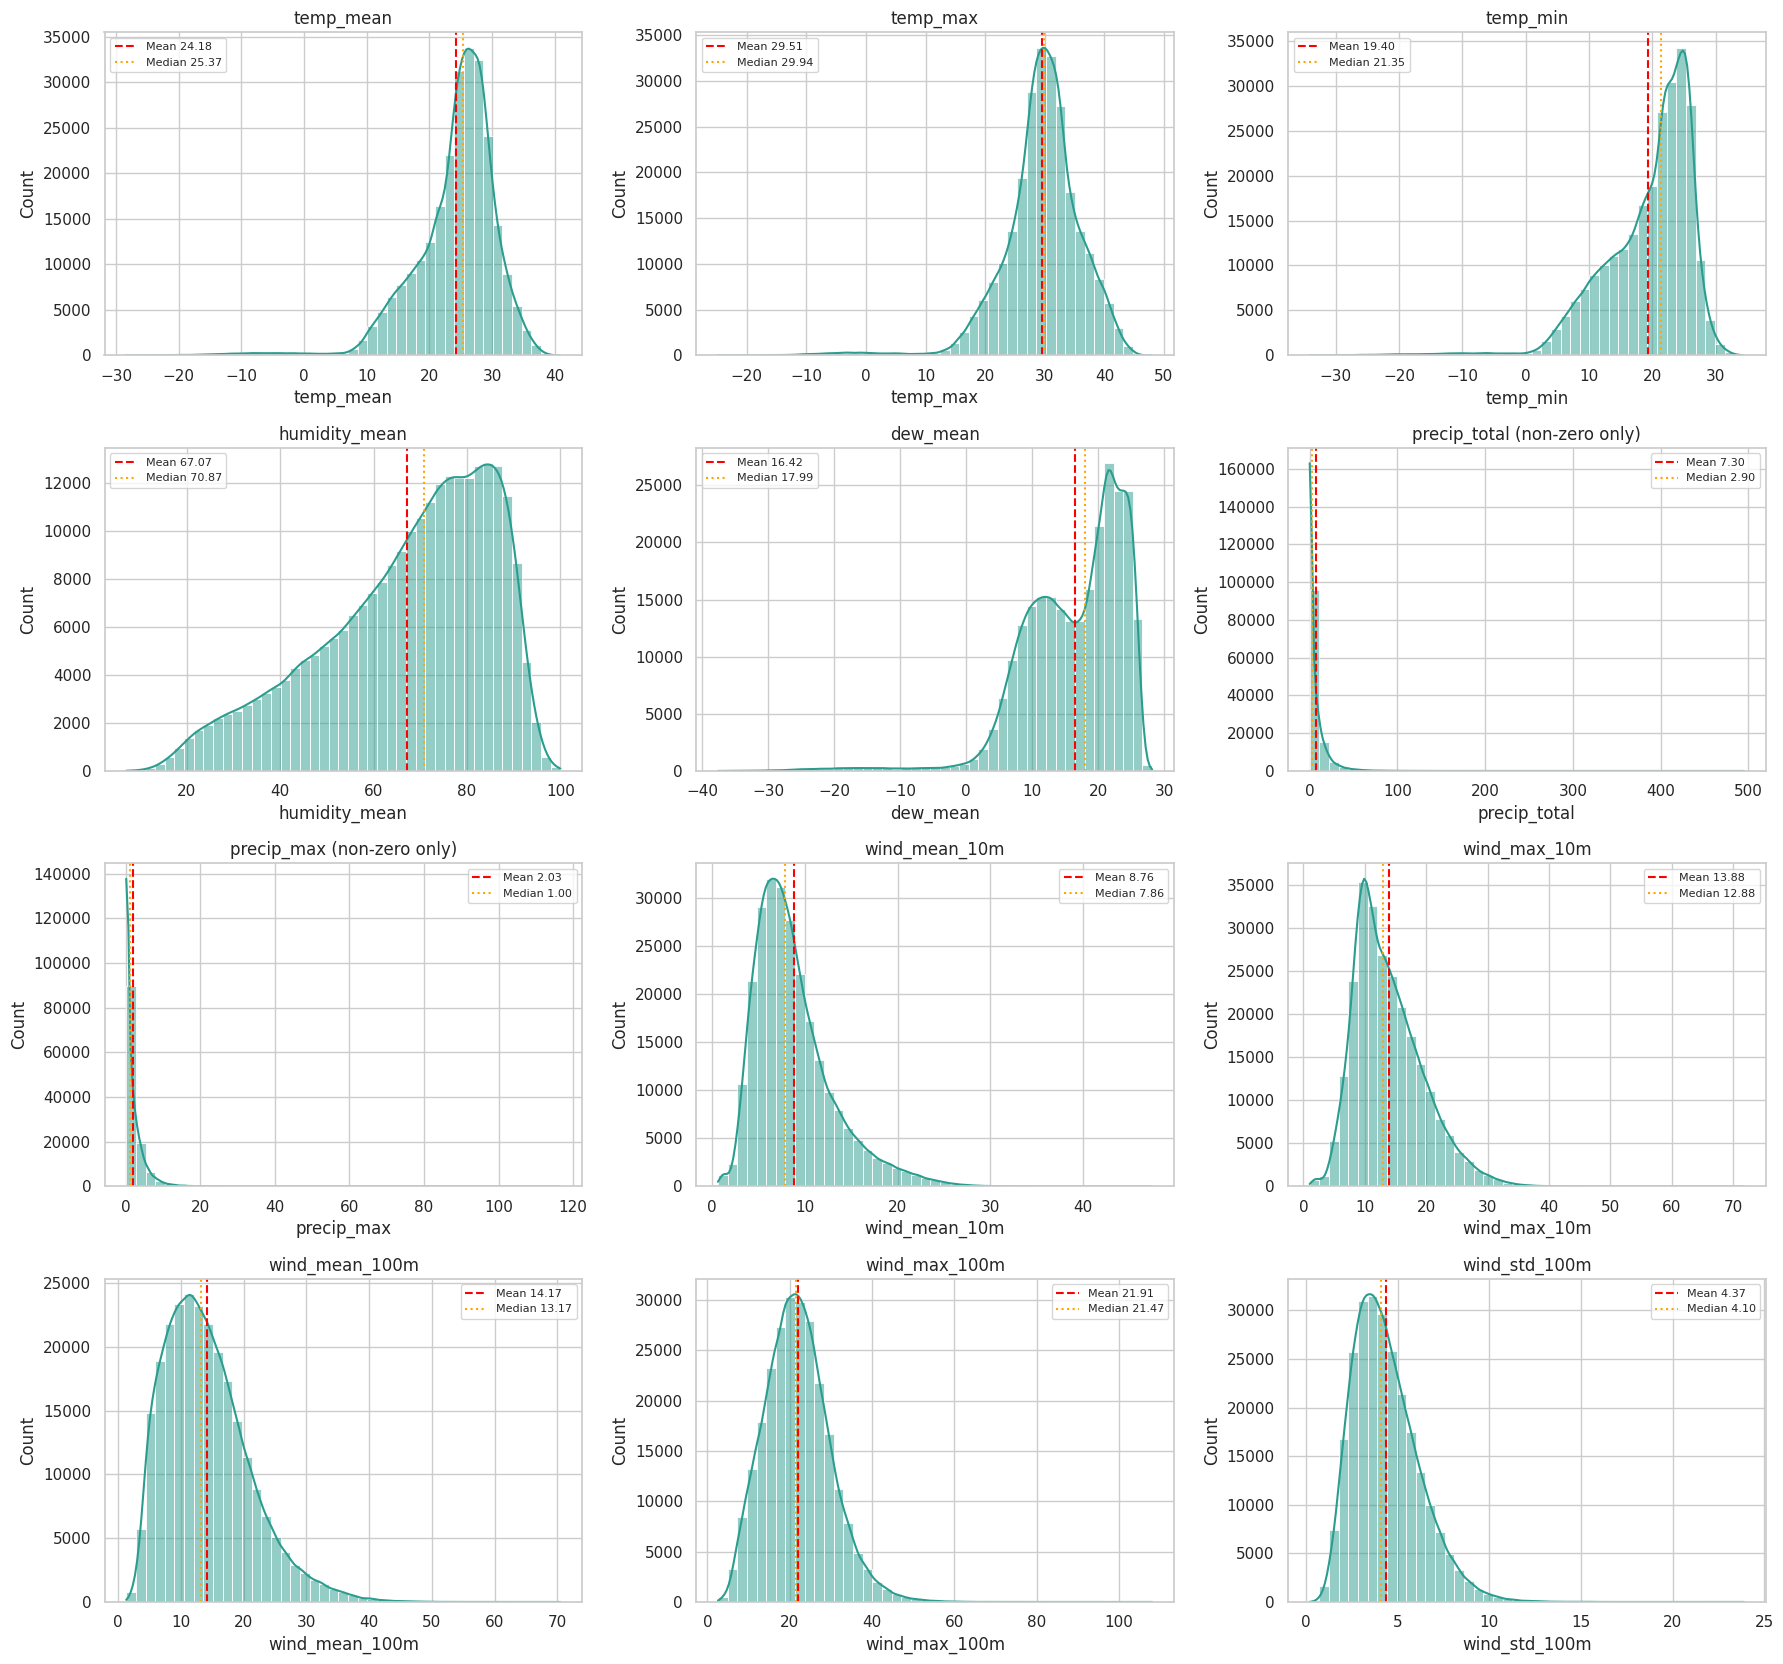

In [17]:
plot_cols = ALL_NUMERIC[:12]
if not plot_cols:
    print("No numeric weather columns are available to plot.")
else:
    n_cols = 3
    n_rows = int(np.ceil(len(plot_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.2 * n_rows), squeeze=False)

    for ax, col in zip(axes.flat, plot_cols):
        values = df[col].dropna()
        if "precip" in col and (values > 0).any():
            values = values[values > 0]
            title = f"{col} (non-zero only)"
        else:
            title = col

        sns.histplot(values, bins=45, kde=len(values) < 500_000, ax=ax, color="#2a9d8f")
        ax.axvline(values.mean(), color="red", linestyle="--", label=f"Mean {values.mean():.2f}")
        ax.axvline(values.median(), color="orange", linestyle=":", label=f"Median {values.median():.2f}")
        ax.set_title(title)
        ax.legend(fontsize=8)

    for ax in axes.flat[len(plot_cols):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "weather_distributions.png"), dpi=140, bbox_inches="tight")
    plt.show()

## 7. Outlier detection

Outliers are calculated separately within each city using the IQR method. This is more meaningful than one national threshold because cities have different climates.

In [18]:
OUTLIER_COLS = [c for c in [
    "temp_mean", "temp_max", "temp_min", "humidity_mean",
    "precip_total", "wind_mean_100m", "wind_max_100m", "pressure_mean"
] if c in df.columns]

outlier_rows = []
for city, city_df in df.groupby("city"):
    for col in OUTLIER_COLS:
        values = city_df[col].dropna()
        if values.empty:
            continue
        q1, q3 = values.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        count = int(((values < lower) | (values > upper)).sum())
        outlier_rows.append({
            "city": city, "column": col, "lower_fence": lower, "upper_fence": upper,
            "outlier_count": count, "outlier_pct": count / len(values) * 100
        })

outlier_detail = pd.DataFrame(outlier_rows)
outlier_summary = (outlier_detail.groupby("column")
                   .agg(total_outliers=("outlier_count", "sum"),
                        mean_city_outlier_pct=("outlier_pct", "mean"),
                        max_city_outlier_pct=("outlier_pct", "max"))
                   .sort_values("mean_city_outlier_pct", ascending=False))

display(outlier_summary.round(2))
print("City-variable combinations with the highest outlier percentages:")
display(outlier_detail.nlargest(20, "outlier_pct").round(2))

,total_outliers,mean_city_outlier_pct,max_city_outlier_pct
column,,,
precip_total,38688,15.290,22.150
wind_mean_100m,6502,2.570,11.210
wind_max_100m,4849,1.920,4.960
humidity_mean,2189,0.870,5.380
temp_min,1553,0.610,6.450
temp_mean,720,0.280,2.690
temp_max,357,0.140,1.030
pressure_mean,111,0.040,0.600


City-variable combinations with the highest outlier percentages:


,city,column,lower_fence,upper_fence,outlier_count,outlier_pct
212,Jodhpur,precip_total,0.000,0.000,1144,22.150
260,Kota,precip_total,-0.450,0.750,1115,21.590
380,Rajkot,precip_total,-0.300,0.500,1045,20.240
348,Prayagraj,precip_total,-1.800,3.000,1027,19.890
28,Ahmedabad,precip_total,-0.450,0.750,1020,19.750
276,Lucknow,precip_total,-1.650,2.750,1020,19.750
68,Bhopal,precip_total,-1.800,3.000,1016,19.670
20,Agra,precip_total,-0.900,1.500,1002,19.400
124,Delhi,precip_total,-1.050,1.750,994,19.250
172,Indore,precip_total,-1.650,2.750,987,19.110


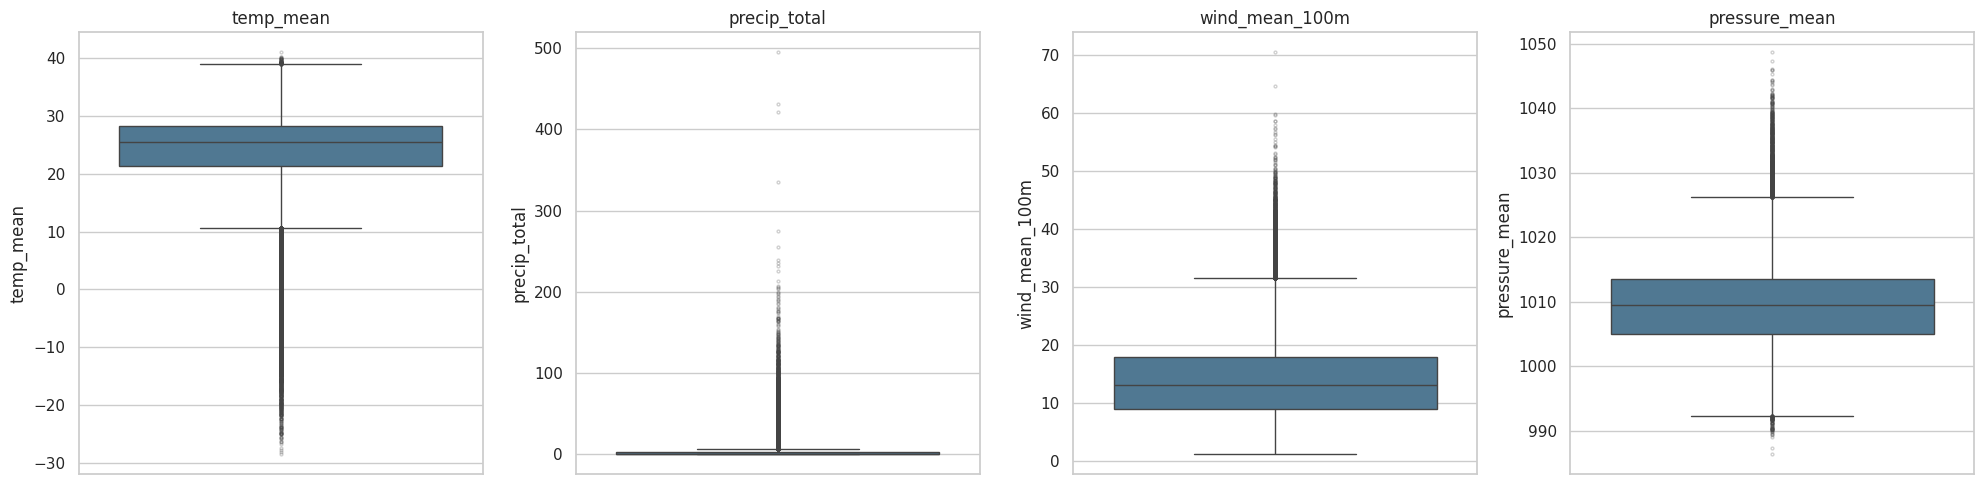

In [19]:
box_cols = [c for c in [
    "temp_mean", "precip_total", "wind_mean_100m", "pressure_mean"
] if c in df.columns]

if box_cols:
    fig, axes = plt.subplots(1, len(box_cols), figsize=(5 * len(box_cols), 5), squeeze=False)
    for ax, col in zip(axes.flat, box_cols):
        sns.boxplot(y=df[col], ax=ax, color="#457b9d", showfliers=True,
                    flierprops={"markersize": 2, "alpha": 0.25})
        ax.set_title(col)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "weather_boxplots.png"), dpi=140, bbox_inches="tight")
    plt.show()

## 8. Physical consistency checks

In [20]:
checks = []

def add_check(name, mask):
    checks.append({"check": name, "violations": int(mask.fillna(False).sum())})

if {"temp_max", "temp_mean"}.issubset(df.columns):
    add_check("temp_max >= temp_mean", df["temp_max"] < df["temp_mean"])
if {"temp_mean", "temp_min"}.issubset(df.columns):
    add_check("temp_mean >= temp_min", df["temp_mean"] < df["temp_min"])
if {"precip_total", "precip_max"}.issubset(df.columns):
    add_check("precip_total >= precip_max", df["precip_total"] < df["precip_max"])
if {"wind_max_100m", "wind_mean_100m"}.issubset(df.columns):
    add_check("wind_max_100m >= wind_mean_100m", df["wind_max_100m"] < df["wind_mean_100m"])
if {"rain_occurred", "precip_total"}.issubset(df.columns):
    add_check("rain flag agrees with precipitation",
              (df["precip_total"] > 0) != (df["rain_occurred"] == 1))
if "humidity_mean" in df.columns:
    add_check("humidity is between 0 and 100",
              (df["humidity_mean"] < 0) | (df["humidity_mean"] > 100))
if "precip_total" in df.columns:
    add_check("precipitation is non-negative", df["precip_total"] < 0)

consistency_report = pd.DataFrame(checks)
consistency_report["status"] = np.where(consistency_report["violations"] == 0, "OK", "REVIEW")
display(consistency_report)

,check,violations,status
0,temp_max >= temp_mean,0,OK
1,temp_mean >= temp_min,0,OK
2,precip_total >= precip_max,0,OK
3,wind_max_100m >= wind_mean_100m,0,OK
4,rain flag agrees with precipitation,0,OK
5,humidity is between 0 and 100,0,OK
6,precipitation is non-negative,0,OK


## 9. Correlation and redundant-feature analysis

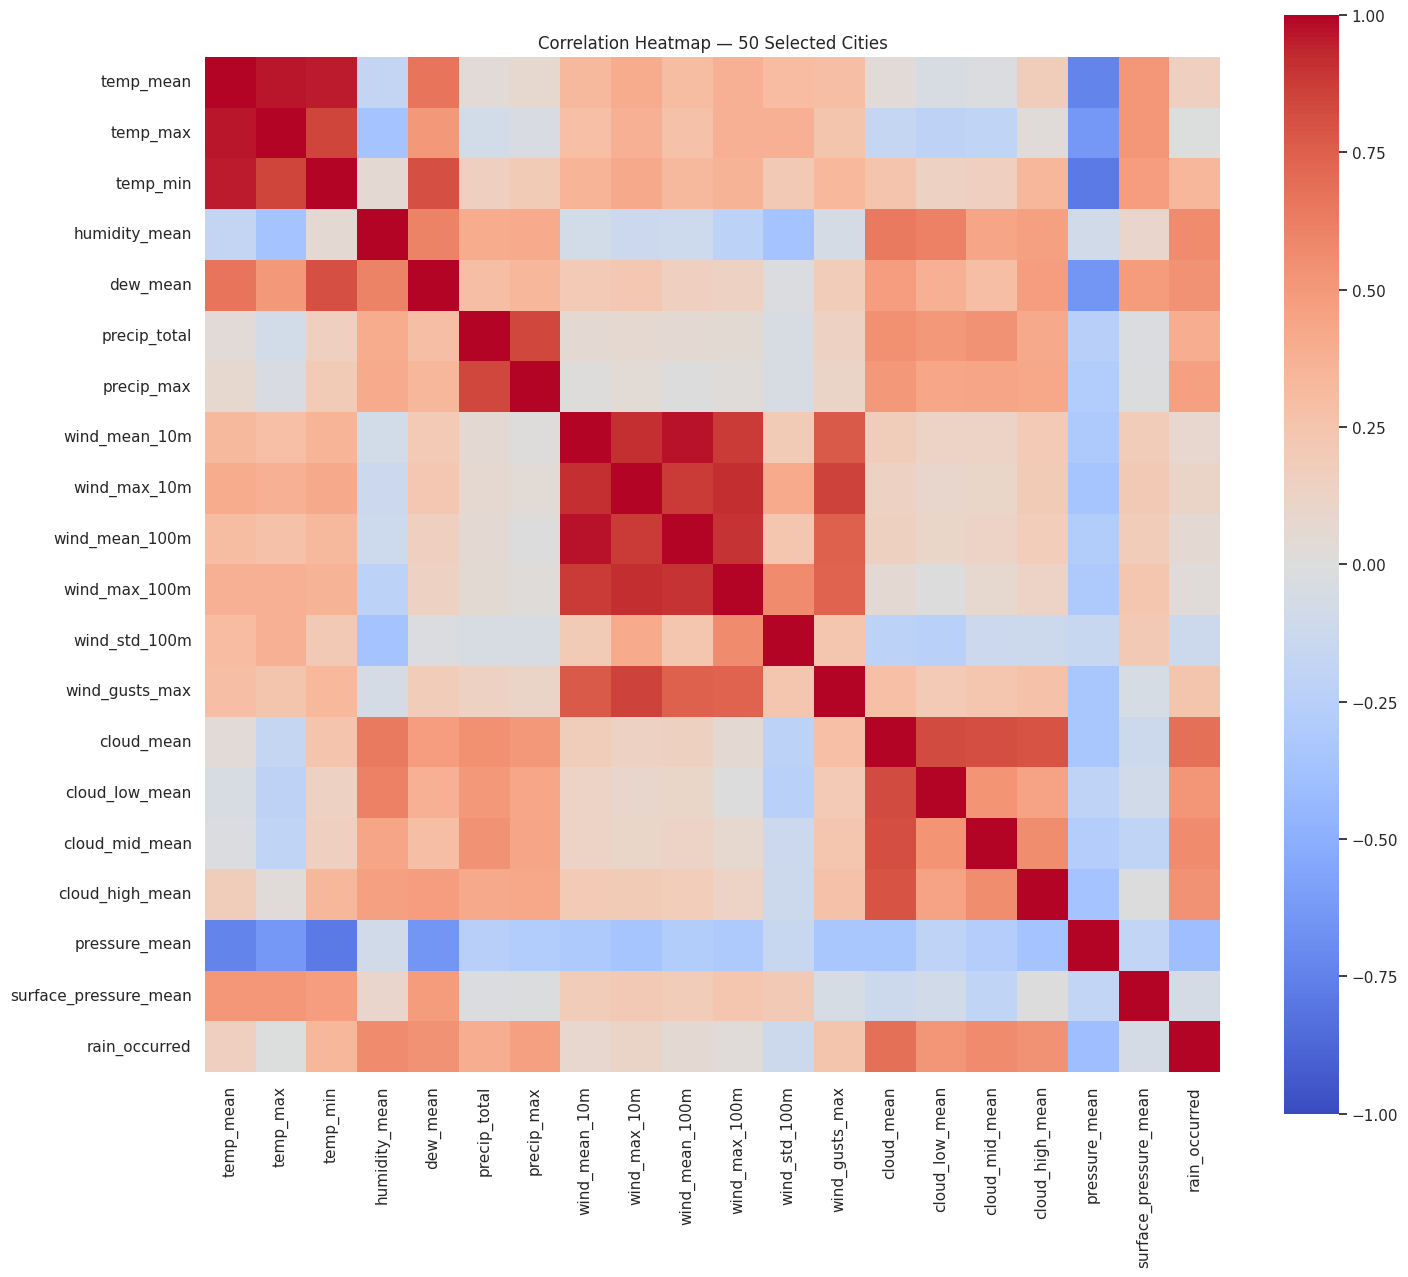

,feature_1,feature_2,correlation,decision
113,wind_mean_10m,wind_mean_100m,0.976,multicollinearity risk — review before modelling
0,temp_mean,temp_max,0.962,multicollinearity risk — review before modelling
1,temp_mean,temp_min,0.956,multicollinearity risk — review before modelling
125,wind_max_10m,wind_max_100m,0.918,multicollinearity risk — review before modelling
112,wind_mean_10m,wind_max_10m,0.909,multicollinearity risk — review before modelling
135,wind_mean_100m,wind_max_100m,0.901,multicollinearity risk — review before modelling
124,wind_max_10m,wind_mean_100m,0.882,multicollinearity risk — review before modelling
114,wind_mean_10m,wind_max_100m,0.878,multicollinearity risk — review before modelling
127,wind_max_10m,wind_gusts_max,0.852,multicollinearity risk — review before modelling
19,temp_max,temp_min,0.850,multicollinearity risk — review before modelling


In [21]:
corr_cols = [c for c in ALL_NUMERIC if df[c].nunique(dropna=True) > 1]
corr = df[corr_cols].corr()

plt.figure(figsize=(max(10, len(corr_cols) * 0.75), max(8, len(corr_cols) * 0.65)))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=len(corr_cols) <= 14, fmt=".2f", square=True)
plt.title("Correlation Heatmap — 50 Selected Cities")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "weather_correlation_heatmap.png"), dpi=140, bbox_inches="tight")
plt.show()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = (upper.stack().rename("correlation").reset_index()
             .rename(columns={"level_0": "feature_1", "level_1": "feature_2"}))
high_corr = high_corr[high_corr["correlation"].abs() >= 0.85]
high_corr["decision"] = np.where(
    high_corr["correlation"].abs() >= 0.98,
    "near duplicate — consider dropping one",
    "multicollinearity risk — review before modelling",
)
display(high_corr.reindex(high_corr["correlation"].abs().sort_values(ascending=False).index))

## 10. Comparison of the selected cities

,city,records,avg_temperature,total_precipitation,avg_humidity,avg_wind_100m
0,Abbigeri,5164,25.532,11056.400,61.709,20.319
1,Agartala,5164,24.908,25356.000,78.573,13.916
2,Agra,5164,24.803,10588.400,62.259,14.073
3,Ahmedabad,5164,27.036,13087.200,56.020,16.818
4,Aizawl,5164,18.399,25002.500,80.495,7.350
5,Amritsar,5164,22.870,10437.300,66.983,11.553
6,Badru Khan,5164,23.532,9961.700,64.693,13.862
7,Bhagsar,5164,24.405,6689.700,59.611,12.855
8,Bhopal,5164,24.984,18535.000,57.244,16.659
9,Chandigarh,5164,23.060,11243.100,61.982,14.405


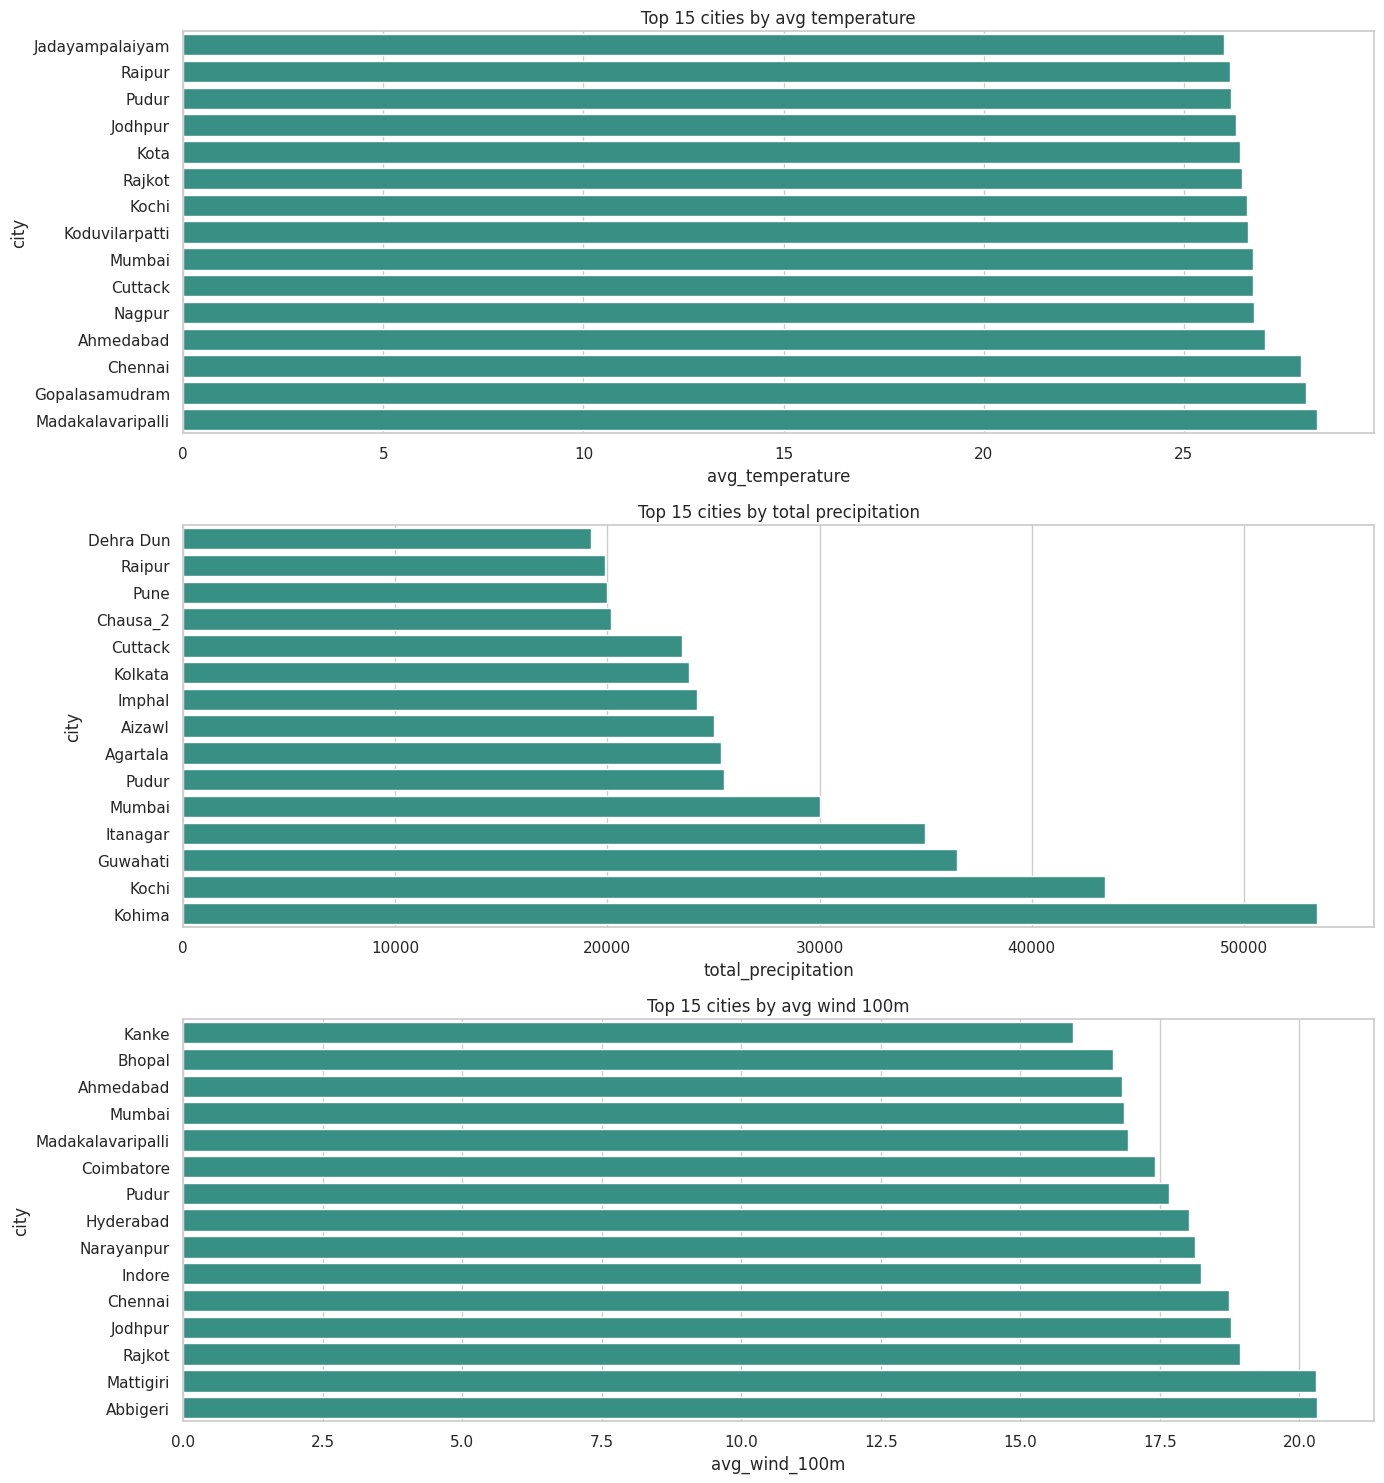

In [22]:
city_agg = {"records": ("date", "size")}
if "temp_mean" in df.columns:
    city_agg["avg_temperature"] = ("temp_mean", "mean")
if "precip_total" in df.columns:
    city_agg["total_precipitation"] = ("precip_total", "sum")
if "humidity_mean" in df.columns:
    city_agg["avg_humidity"] = ("humidity_mean", "mean")
if "wind_mean_100m" in df.columns:
    city_agg["avg_wind_100m"] = ("wind_mean_100m", "mean")

city_summary = df.groupby("city").agg(**city_agg).reset_index()
display(city_summary.sort_values(city_summary.columns[1]).head(50))

metrics = [c for c in ["avg_temperature", "total_precipitation", "avg_wind_100m"]
           if c in city_summary.columns]
if metrics:
    fig, axes = plt.subplots(len(metrics), 1, figsize=(14, 5 * len(metrics)), squeeze=False)
    for ax, metric in zip(axes.flat, metrics):
        top = city_summary.nlargest(15, metric).sort_values(metric)
        sns.barplot(data=top, x=metric, y="city", ax=ax, color="#2a9d8f")
        ax.set_title(f"Top 15 cities by {metric.replace('_', ' ')}")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "city_comparison.png"), dpi=140, bbox_inches="tight")
    plt.show()

## 11. Export analysis tables

In [23]:
stats.to_csv(os.path.join(OUTPUT_DIR, "descriptive_statistics.csv"))
missing.to_csv(os.path.join(OUTPUT_DIR, "missing_values.csv"))
coverage.to_csv(os.path.join(OUTPUT_DIR, "city_coverage.csv"))
outlier_detail.to_csv(os.path.join(OUTPUT_DIR, "outlier_details.csv"), index=False)
consistency_report.to_csv(os.path.join(OUTPUT_DIR, "consistency_checks.csv"), index=False)
high_corr.to_csv(os.path.join(OUTPUT_DIR, "high_correlation_pairs.csv"), index=False)
city_summary.to_csv(os.path.join(OUTPUT_DIR, "city_summary.csv"), index=False)

print("All tables and charts saved in:", OUTPUT_DIR)
print("Use Kaggle's Output panel to download them after the notebook finishes.")

All tables and charts saved in: /kaggle/working/weather_eda_50_cities
Use Kaggle's Output panel to download them after the notebook finishes.


## Interpretation guide

- A high missing percentage means that feature may need removal or careful imputation.
- IQR outliers are observations for review, not automatic errors; extreme rainfall and temperature can be real events.
- A physical consistency violation is more likely to indicate a processing or data-quality problem.
- Correlation above 0.85 can create multicollinearity; correlation above 0.98 suggests a near-duplicate feature.
- City-wise thresholds are used for outliers because a normal value in one climate zone can look extreme in another.